# Data Analysis

In this tutorial you will be performing basic inference using your trained model, and then analyse output based on your defined metrics.

Use only your test set in this analysis to ensure data integrity.

In [1]:
import sys
sys.path.append('..')
from config import TEST_PARQUET
import pandas as pd

df = pd.read_parquet(TEST_PARQUET)
df.head()

,id,audio,text,segment_start_time,segment_end_time,duration
0,atco2_test-set-1h_LSZB_BERN_Approach_127_3MHz_...,{'bytes': b'RIFFd\xd5\x03\x00WAVEfmt \x10\x00\...,oscar oscar papa charlie kilo it s for ifr fly...,0.13,7.98,7.85
1,atco2_test-set-1h_LSZB_BERN_Tower_121_0MHz_202...,{'bytes': b'RIFFd\xc4\x00\x00WAVEfmt \x10\x00\...,ja that is copied roger hold position,9.78,11.35,1.57
2,atco2_test-set-1h_LSGS_SION_Ground_Control_121...,{'bytes': b'RIFFd0\x03\x00WAVEfmt \x10\x00\x00...,merci two two zero degrees three knots four tw...,4.05,10.58,6.53
3,atco2_test-set-1h_LZIB_STEFANIK_Tower_118_3MHz...,{'bytes': b'RIFF$I\x02\x00WAVEfmt \x10\x00\x00...,oscar mike echo lima echo taxi between anchors...,0.00,4.68,4.68
4,atco2_test-set-1h_LKPR_RUZYNE_Tower_134_560MHz...,{'bytes': b'RIFFd*\x04\x00WAVEfmt \x10\x00\x00...,silesia seven six two continue charlie lima qu...,0.00,8.53,8.53


Load your trained model.

In [2]:
from transformers import WhisperProcessor, WhisperForConditionalGeneration
import torch

processor = WhisperProcessor.from_pretrained("openai/whisper-small")
model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small")
model.eval()

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

WhisperForConditionalGeneration(
  (model): WhisperModel(
    (encoder): WhisperEncoder(
      (conv1): Conv1d(80, 768, kernel_size=(3,), stride=(1,), padding=(1,))
      (conv2): Conv1d(768, 768, kernel_size=(3,), stride=(2,), padding=(1,))
      (embed_positions): Embedding(1500, 768)
      (layers): ModuleList(
        (0-11): 12 x WhisperEncoderLayer(
          (self_attn): WhisperAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=False)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (f

Transcribe every file in the test set using your model.

In [3]:
import io
import librosa
import torch

def transcribe(audio_bytes):
    # 1. Load audio
    audio, _ = librosa.load(io.BytesIO(audio_bytes['bytes']), sr=16000)

    # 2. Process inputs and include the attention_mask
    inputs = processor(audio, sampling_rate=16000, return_tensors="pt")
    input_features = inputs.input_features
    # Some versions of Whisper require the attention_mask to avoid 'unexpected behavior'
    attention_mask = getattr(inputs, "attention_mask", None)

    # 3. Explicit generation settings
    generated_ids = model.generate(
        input_features,
        attention_mask=attention_mask,
        language="en",       # Replace with 'zh' or None (for auto-detect)
        task="transcribe",   # Ensures it doesn't default to translation
        return_timestamps=False
    )

    return processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

df['transcription'] = df['audio'].apply(transcribe)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensA

In [4]:
df[['text', 'transcription']].head()

,text,transcription
0,oscar oscar papa charlie kilo it s for ifr fly...,Oscar Oscar Papa Charlie kill it for IFR flig...
1,ja that is copied roger hold position,"Yeah, that's copy, Roger, hold position."
2,merci two two zero degrees three knots four tw...,"Thank you 220 degrees, 3 knots, Fato 07, QNH ..."
3,oscar mike echo lima echo taxi between anchors...,"Oscar Maeg, E-M-Eco takes you between Hankers..."
4,silesia seven six two continue charlie lima qu...,"Sir, the 7-6-2, continue channeling, we must ..."


## Analysis: WER per sample

We compute Word Error Rate for each individual sample, then visualise the distribution and identify the best and worst examples.

In [6]:
# Compute per-sample WER
# WER = (S + D + I) / N  where S=substitutions, D=deletions, I=insertions, N=words in reference

def wer(reference, hypothesis):
    ref = reference.lower().split()
    hyp = hypothesis.lower().split()
    n = len(ref)
    if n == 0:
        return 0.0

    # Dynamic programming edit distance on word level
    d = [[0] * (len(hyp) + 1) for _ in range(len(ref) + 1)]
    for i in range(len(ref) + 1):
        d[i][0] = i
    for j in range(len(hyp) + 1):
        d[0][j] = j
    for i in range(1, len(ref) + 1):
        for j in range(1, len(hyp) + 1):
            cost = 0 if ref[i-1] == hyp[j-1] else 1
            d[i][j] = min(d[i-1][j] + 1,       # deletion
                          d[i][j-1] + 1,         # insertion
                          d[i-1][j-1] + cost)    # substitution
    return d[len(ref)][len(hyp)] / n

df['wer'] = df.apply(lambda row: wer(row['text'], row['transcription']), axis=1)
df['wer_pct'] = df['wer'] * 100

print(f"Mean WER:   {df['wer_pct'].mean():.1f}%")
print(f"Median WER: {df['wer_pct'].median():.1f}%")
print(f"Min WER:    {df['wer_pct'].min():.1f}%")
print(f"Max WER:    {df['wer_pct'].max():.1f}%")

Mean WER:   87.2%
Median WER: 81.2%
Min WER:    18.8%
Max WER:    300.0%


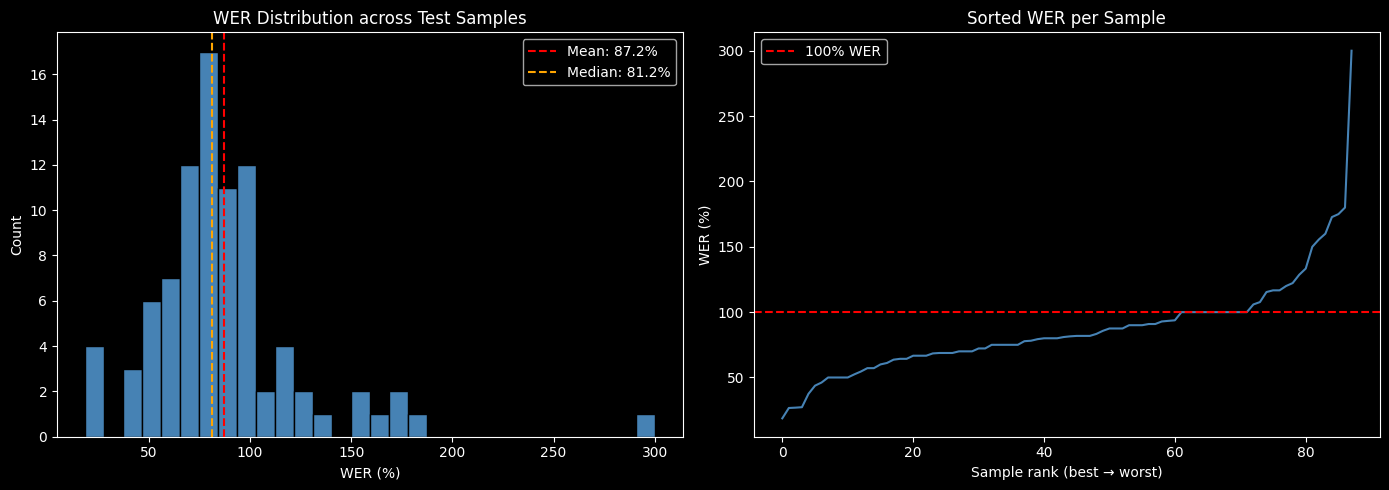

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of WER distribution
axes[0].hist(df['wer_pct'], bins=30, edgecolor='black', color='steelblue')
axes[0].axvline(df['wer_pct'].mean(), color='red', linestyle='--', label=f"Mean: {df['wer_pct'].mean():.1f}%")
axes[0].axvline(df['wer_pct'].median(), color='orange', linestyle='--', label=f"Median: {df['wer_pct'].median():.1f}%")
axes[0].set_xlabel('WER (%)')
axes[0].set_ylabel('Count')
axes[0].set_title('WER Distribution across Test Samples')
axes[0].legend()

# Sorted WER per sample (cumulative view)
sorted_wer = np.sort(df['wer_pct'])
axes[1].plot(sorted_wer, color='steelblue')
axes[1].axhline(100, color='red', linestyle='--', label='100% WER')
axes[1].set_xlabel('Sample rank (best → worst)')
axes[1].set_ylabel('WER (%)')
axes[1].set_title('Sorted WER per Sample')
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
# Best performing samples (lowest WER)
print("=== Best samples (lowest WER) ===")
best = df.nsmallest(5, 'wer')[['text', 'transcription', 'wer_pct']]
for _, row in best.iterrows():
    print(f"WER: {row['wer_pct']:.1f}%")
    print(f"  REF: {row['text']}")
    print(f"  HYP: {row['transcription']}")
    print()

=== Best samples (lowest WER) ===
WER: 18.8%
  REF: hotel kilo delta now to whiskey one is approved if you remain outside romeo eight two
  HYP:  Hotel Kilo Delta, now to whiskey one is approved if you remain outside Romeo 8.

WER: 26.7%
  REF: nav checker five one one we are on the way to your airfield and i would like to know what is the actual ground base you have in your area
  HYP:  We are on the way to your airfield and I would like to know what is the actual cloud space you have in your area?

WER: 26.9%
  REF: oscar oscar papa charlie kilo it s for ifr fly to echo bravo charlie india we have information delta it is for startup and ifr clearance
  HYP:  Oscar Oscar Papa Charlie kill it for IFR flight to Ecopravo Charlie India we have information Delta is for start and IFR clearance

WER: 27.3%
  REF: hotel lima sierra during night time visual departure is not possible
  HYP:  Hotel Lima Sierra during nighttime visual departure is not possible.

WER: 37.5%
  REF: hotel golf delta

In [9]:
# Worst performing samples (highest WER)
print("=== Worst samples (highest WER) ===")
worst = df.nlargest(5, 'wer')[['text', 'transcription', 'wer_pct']]
for _, row in worst.iterrows():
    print(f"WER: {row['wer_pct']:.1f}%")
    print(f"  REF: {row['text']}")
    print(f"  HYP: {row['transcription']}")
    print()

=== Worst samples (highest WER) ===
WER: 300.0%
  REF: affirmatif montana
  HYP:  I'm not gonna talk about that.

WER: 180.0%
  REF: oscar kilo charlie alfa papa squawk seven thousand good bye
  HYP:  Carcota, I'm going to get to the car, it's all good, we're going to get to the car

WER: 175.0%
  REF: kilo bravo victor bern
  HYP:  Well, kill a brown wig to burn.

WER: 172.7%
  REF: on foxtrot cross runway one zero one two one seven five
  HYP:  One faster, faster, faster than I want to, you know, when I want to, I want to stand by.

WER: 160.0%
  REF: ups two nine five established
  HYP:  You're going to stay now, sir. I'm established.



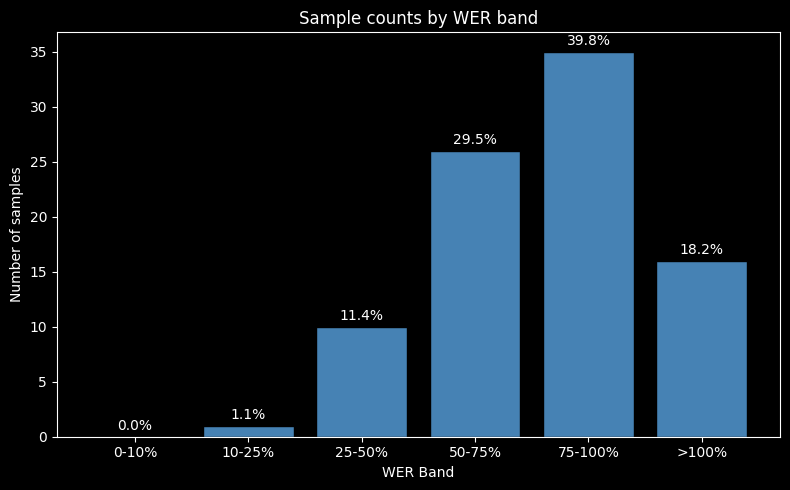

In [10]:
# WER bucketed into bands for a cleaner summary
bins = [0, 10, 25, 50, 75, 100, float('inf')]
labels = ['0-10%', '10-25%', '25-50%', '50-75%', '75-100%', '>100%']
df['wer_band'] = pd.cut(df['wer_pct'], bins=bins, labels=labels)

band_counts = df['wer_band'].value_counts().sort_index()
band_pct = (band_counts / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(band_counts.index, band_counts.values, color='steelblue', edgecolor='black')
for bar, pct in zip(bars, band_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{pct}%', ha='center', va='bottom', fontsize=10)
ax.set_xlabel('WER Band')
ax.set_ylabel('Number of samples')
ax.set_title('Sample counts by WER band')
plt.tight_layout()
plt.show()